# Plot results from fitting $k$ and $m$ to the nude mice

Produces Figures 3c and 3d.

It requires that the parameter estimation has been completed and there exists a file with those results. Edit the location of those files below.

## Load required packages

In [1]:
%matplotlib widget
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from scipy.stats import ttest_ind
from estimator import Estimator
from src import pyxfunc

## User-defined parameters

In [43]:
growth_data_file = "data/growth_data_df.csv"
config_file = "config_files/config_km.json"

bests_file = "bests/km_100.csv"

figure_save_path = "figures/" # Set to None to not save figures
plot_3d_data_save_file = "figures/Figure3d.csv" # Set to None to not save plot data

## Setup

In [3]:
groups = ["Grp. B1 nude (100% C1)", "Grp. B2 nude (80% C1; 20% C11)", "Grp. B3 nude (50% C1; 50% C11)", "Grp. B4 nude (20% C1; 80% C11)", "Grp. B5 nude (100% C11)"]
growth_df = pd.read_csv(growth_data_file)
exclude = [456, 458, 461, 464, 471, 474, 478, 482, 483, 426, 428, 429, 430, 434, 437, 438, 442, 443, 451, 642, 662]
growth_df = growth_df[~(growth_df["id"].isin(exclude))]
es = Estimator(config_file)

## Read in and prep data

In [4]:
bests = pd.read_csv(bests_file)
bests

,index,group,id,g1,g11,m,k,error,winner,log_error
0,1692,Grp. B2 nude (80% C1; 20% C11),460,0.166,0.142,-0.025,-0.010,8686.370697,0.0,9.069510
1,868,Grp. B2 nude (80% C1; 20% C11),460,0.166,0.141,-0.025,-0.010,8704.985181,0.0,9.071651
2,8,Grp. B2 nude (80% C1; 20% C11),460,0.166,0.127,-0.020,-0.010,8749.460075,0.0,9.076747
3,1688,Grp. B2 nude (80% C1; 20% C11),460,0.166,0.142,-0.025,-0.015,8805.163177,0.0,9.083094
4,864,Grp. B2 nude (80% C1; 20% C11),460,0.166,0.141,-0.025,-0.015,8828.586690,0.0,9.085750
...,...,...,...,...,...,...,...,...,...,...
1395,33036,Grp. B4 nude (20% C1; 80% C11),477,0.166,0.142,-0.155,0.120,5744.162532,0.0,8.655939
1396,32492,Grp. B4 nude (20% C1; 80% C11),477,0.166,0.142,-0.145,0.115,5746.957048,0.0,8.656426
1397,29361,Grp. B4 nude (20% C1; 80% C11),477,0.166,0.127,-0.125,0.105,5747.386683,0.0,8.656501
1398,33590,Grp. B4 nude (20% C1; 80% C11),477,0.166,0.142,-0.165,0.125,5751.585504,0.0,8.657231


In [5]:
def plot_scatterplots():
    for i in [1, 2, 3]:
        fig = plt.figure(figsize=(2,2))
        sns.scatterplot(bests[bests["group"]==groups[i]], x="m", y="k", hue="id", palette="bright", marker="o", edgecolors="white", s=5, alpha=.7)
        plt.xlim([-1.1, .1])
        plt.ylim([-.1, 1.1])
        plt.tight_layout()
        plt.legend(prop={"size":5})
        if figure_save_path:
            plt.savefig(figure_save_path+"m_vs_k_{}.svg".format(i))
        plt.show()

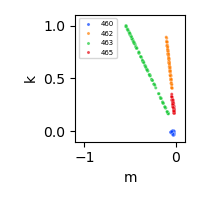

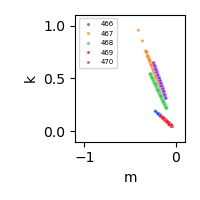

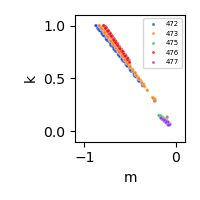

In [6]:
plot_scatterplots()

## Plot optimal values

In [37]:
def plot_results_best(bests):
    plot_results = []
    
    ylim = (growth_df[growth_df["group"].isin(groups)]["size"].max())+10
    xlim = growth_df[growth_df["group"].isin(groups)]["day"].max()+2

    fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(10,5))
    for i in range(1,4):
        axes[0][i-1].set_ylim([-1, np.abs(ylim)])
        axes[0][i-1].set_xlim([6, np.abs(xlim)])
        # Plot true data
        group_df = growth_df[growth_df["group"] == groups[i]]
        for mid in group_df["id"].unique():
            axes[0][i-1].plot(group_df[group_df["id"]==mid]["day"], group_df[group_df["id"]==mid]["size"], color="black", linewidth=1)
            
            # Plot estimated data
            init = es.get_init(groups[i], mid)
            end_time = group_df[group_df["id"]==mid]["day"].max()
            
            g1 = bests[bests["id"]==mid]["g1"].tolist()[0]
            g11 = bests[bests["id"]==mid]["g11"].tolist()[0]
            k = bests[bests["id"]==mid]["k"].tolist()[0]
            m = bests[bests["id"]==mid]["m"].tolist()[0]
            sol = pyxfunc.run(init[0], init[1], init[2], 7.0, end_time, np.inf, es.cutoff_0_raw, es.cutoff_0_percent, init[2], 
                                g1, g11, m, k, 0, 0, 0, 0, 0.01)
            
            sol[0] = np.asarray(sol[0])
            sol[1] = np.asarray(sol[1])
            sol[2] = np.asarray(sol[2])
            sol[3] = np.asarray(sol[3])
            
            # plot the winning subline second so it shows up
            if sol[0][-1] > sol[1][-1]: 
                axes[0][i-1].plot(sol[3], ((sol[1])), color="blue", label="Invasive", alpha=0.6)
                axes[0][i-1].plot(sol[3], ((sol[0])), color="orange", label="Proliferative", alpha=0.8)
                color = "orange"
            else:
                axes[0][i-1].plot(sol[3], ((sol[0])), color="orange", label="Invasive", alpha=0.8)
                axes[0][i-1].plot(sol[3], ((sol[1])), color="blue", label="Proliferative", alpha=0.6)
                color = "blue"
    
            # plot the ratios
            axes[1][i-1].plot(sol[0]+sol[1], sol[0]/(sol[0]+sol[1]), color="orange", label="Invasive")
            axes[1][i-1].plot(sol[0]+sol[1], sol[1]/(sol[0]+sol[1]), color="blue", label="Proliferative")

            plot_results += [np.concat([[groups[i], mid, "C1"], sol[0]])]
            plot_results += [np.concat([[groups[i], mid, "C11"], sol[1]])]
            
            axes[0][i-1].set_title(groups[i][5:7])
  
    axes[1][0].set_ylabel("Percentage of subclone")
    plt.tight_layout()
    if figure_save_path:
        plt.savefig(figure_save_path+"nude_admix_predictions.svg")
    plt.show()

    return plot_results

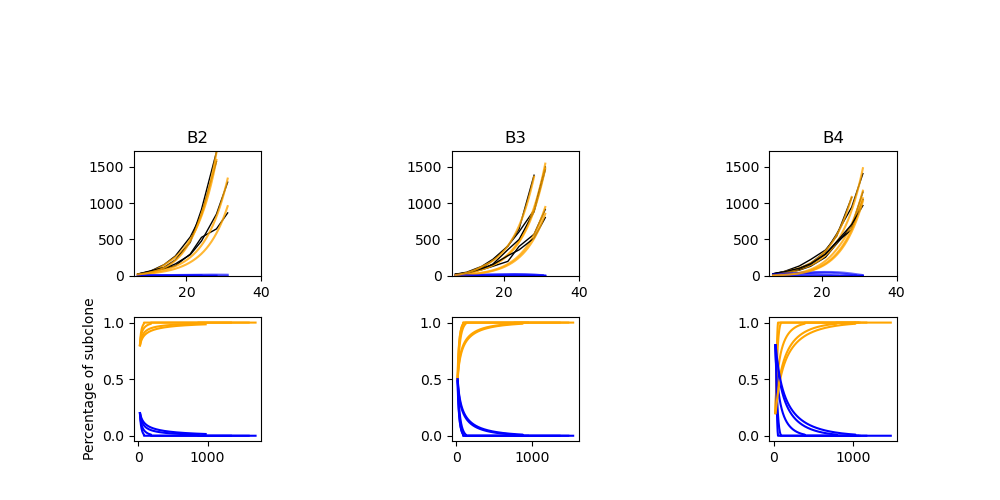

In [38]:
plot_results = plot_results_best(bests)

In [44]:
plot_results = pd.DataFrame(plot_results, columns=["Group", "ID", "Subclone"]+np.arange(7, 31.01, 0.01).tolist())
if plot_3d_data_save_file:
    plot_results.to_csv(plot_3d_data_save_file, index=False)

In [9]:
plt.close("all")